In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
df= pd.read_csv('/content/CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

In [4]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [8]:
df['CREDIT_LIMIT']= df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS']= df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

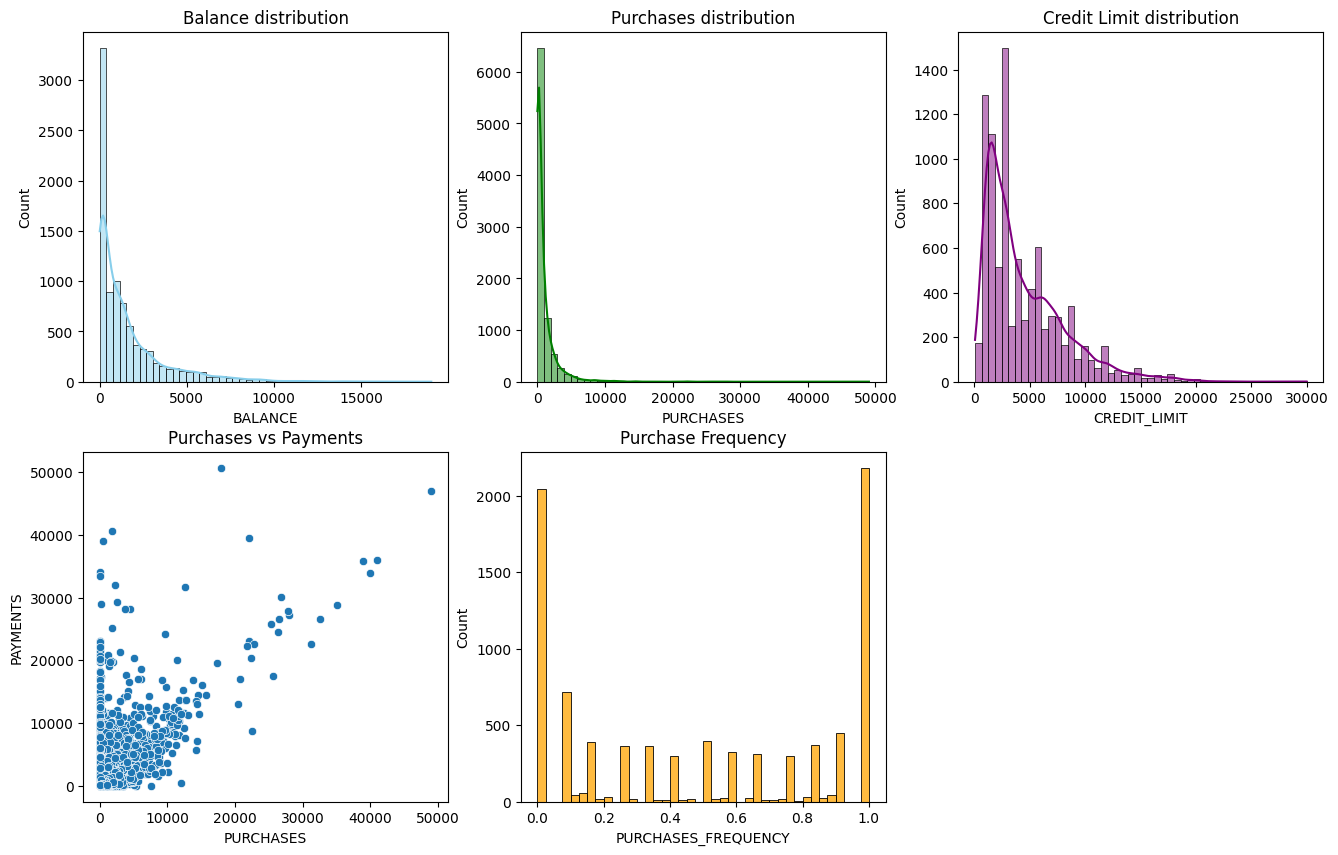

In [9]:
plt.figure(figsize=(16,10))
plt.subplot(2,3,1)
sns.histplot(df["BALANCE"], bins=50, kde=True, color="skyblue")
plt.title("Balance distribution")

plt.subplot(2,3,2)
sns.histplot(df["PURCHASES"], bins=50, kde=True, color="green")
plt.title("Purchases distribution")

plt.subplot(2,3,3)
sns.histplot(df["CREDIT_LIMIT"], bins=50, kde=True, color="purple")
plt.title("Credit Limit distribution")

plt.subplot(2,3,4)
sns.scatterplot(x=df["PURCHASES"], y=df["PAYMENTS"])
plt.title("Purchases vs Payments")

plt.subplot(2,3,5)
sns.histplot(df["PURCHASES_FREQUENCY"], bins=40, color="orange")
plt.title("Purchase Frequency")
plt.show()

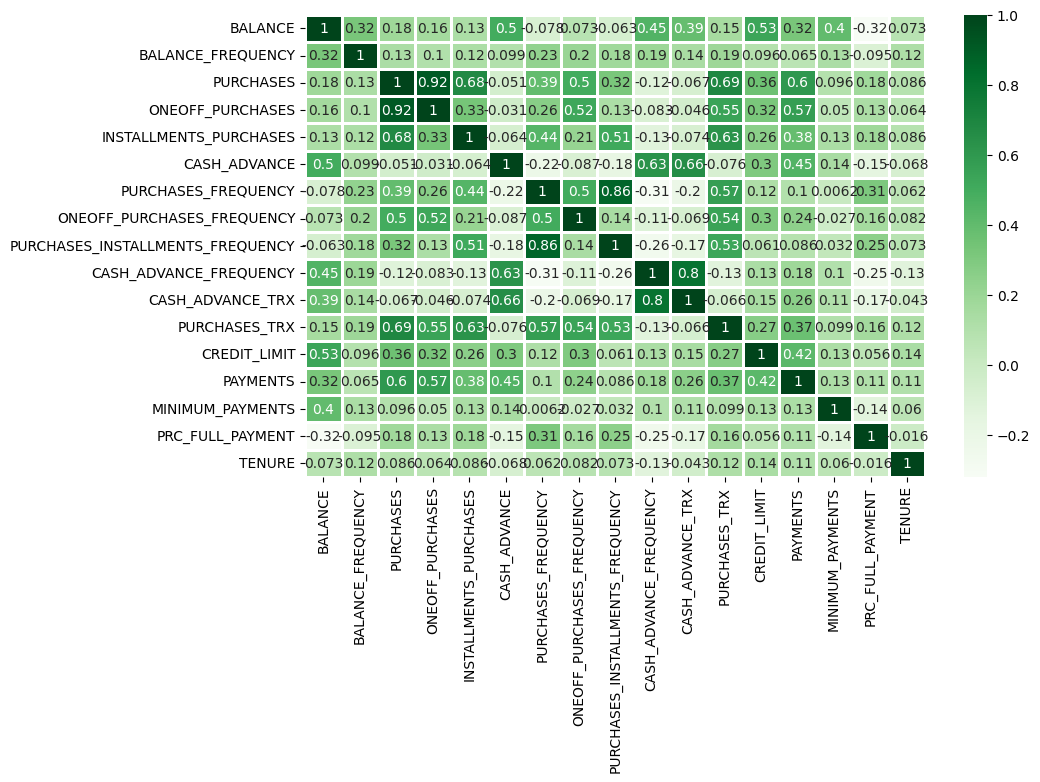

In [10]:
plt.figure(figsize= (10,6))
sns.heatmap(df.drop(['CUST_ID'], axis=1).corr(), annot=True, linewidths=1, cmap='Greens')
plt.show()

In [11]:
df= df.drop(["CUST_ID"], axis=1)

In [12]:
df_fe = df.copy()
one = 1

df_fe["PURCHASES_PER_TRX"] = df_fe["PURCHASES"] / (df_fe["PURCHASES_TRX"] + one)
df_fe["CASH_ADVANCE_PER_TRX"] = df_fe["CASH_ADVANCE"] / (df_fe["CASH_ADVANCE_TRX"] + one)
df_fe["PAYMENT_TO_BALANCE"] = df_fe["PAYMENTS"] / (df_fe["BALANCE"] + one)
df_fe["MINPAY_TO_BALANCE"] = df_fe["MINIMUM_PAYMENTS"] / (df_fe["BALANCE"] + one)
df_fe["CASH_ADVANCE_SHARE"] = df_fe["CASH_ADVANCE"] / (df_fe["PURCHASES"] + df_fe["CASH_ADVANCE"] + one)
df_fe["INSTALLMENT_SHARE"] = df_fe["INSTALLMENTS_PURCHASES"] / (df_fe["PURCHASES"] + one)
df_fe["ONEOFF_SHARE"] = df_fe["ONEOFF_PURCHASES"] / (df_fe["PURCHASES"] + one)

df_fe[["PURCHASES_PER_TRX","CASH_ADVANCE_PER_TRX","PAYMENT_TO_BALANCE","CASH_ADVANCE_SHARE","INSTALLMENT_SHARE","ONEOFF_SHARE"]].describe().T

,count,mean,std,min,25%,50%,75%,max
PURCHASES_PER_TRX,8950.0,58.129748,107.141354,0.0,9.818229,35.872548,68.913654,4486.250000
CASH_ADVANCE_PER_TRX,8950.0,146.634111,316.148808,0.0,0.000000,0.000000,187.083026,7418.225705
PAYMENT_TO_BALANCE,8950.0,16.120941,205.549987,0.0,0.329309,1.400489,7.532226,14229.882480
CASH_ADVANCE_SHARE,8950.0,0.378811,0.442150,0.0,0.000000,0.000000,0.950476,0.999962
INSTALLMENT_SHARE,8950.0,0.400698,0.849339,0.0,0.000000,0.185036,0.969317,66.950000
ONEOFF_SHARE,8950.0,0.377199,0.423428,0.0,0.000000,0.109925,0.871232,1.798389


In [98]:
df_log = df_fe.copy()

for col in df_log.columns:
    df_log[col] = np.log1p(df_log[col])

In [99]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
x_scaled = scaler.fit_transform(df_log)

In [64]:
wcss = []
ss = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(x_scaled)
    labels = model.predict(x_scaled)
    ss1 = silhouette_score(x_scaled, labels)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.4431944341428987
0.25860039410177754
0.2999511942245884
0.29628701204010083
0.26247074370360735
0.2497261653341817
0.25189665821597884
0.2514651087942569
0.24789864658947916


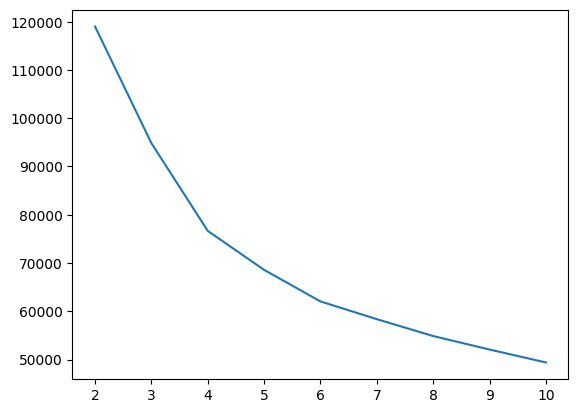

In [65]:
plt.plot(range(2,11), wcss)

In [67]:
# plt.plot(range(2,11), ss)

Model Training

In [76]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = model.fit_predict(x_scaled)
df_log["cluster"] = clusters

In [77]:
silhouette_score(x_scaled,clusters)

np.float64(0.25860039410177754)

In [78]:
df_log["cluster"].value_counts()

,count
cluster,
1,5274
2,2429
0,1247


In [79]:
df_cluster = df.copy()
df_cluster["cluster"] = clusters

df_cluster.groupby("cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,98.854052,0.351056,347.095365,198.447939,149.208372,339.287088,0.292528,0.068749,0.217629,0.036872,0.813152,4.704090,3707.890493,1191.621280,177.968350,0.232522,11.340818
1,1432.633161,0.963652,1596.198043,943.084702,653.467050,525.636819,0.731751,0.314614,0.549468,0.074957,1.761851,23.369928,4716.357125,1868.066704,870.404759,0.195078,11.614524
2,2603.158260,0.959861,52.493561,33.355772,19.187880,2291.312010,0.067765,0.027581,0.038055,0.316277,7.727872,1.043228,4415.817708,1718.197589,1131.936736,0.023445,11.396871


Cluster 0: Use the credit card occasionally, Make small purchases, Usually pay their balance fully, Maintain very low balance

Cluster 1: Use card very frequently, Make many purchases, Spend consistently, Pay a large portion of their balance

Cluster 2: Rarely use the card for purchases, Mainly withdraw cash advances, Maintain very high outstanding balances, Mostly pay only minimum payments

In [80]:
df_cluster

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,1
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [32.5, 32.5, 63.75, 63.75],
  [10.0, 10.0, 48.125, 48.125],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [95.0, 95.0, 112.5, 112.5],
  [29.0625, 29.0625, 103.75, 103.75],
  [135.0, 135.0, 145.0, 145.0],
  [155.0, 155.0, 165.0, 165.0],
  [175.0, 175.0, 185.0, 185.0],
  [160.0, 160.0, 180.0, 180.0],
  [195.0, 195.0, 205.0, 205.0],
  [170.0, 170.0, 200.0, 200.0],
  [140.0, 140.0, 185.0, 185.0],
  [215.0, 215.0, 225.0, 225.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [220.0, 220.0, 243.75, 243.75],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [305.0, 305.0, 315.0, 315.0],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [310.0, 310.0, 332.5, 332.5],
  [282.5, 282.5, 321.25, 321.25],
  [231.875, 231.87

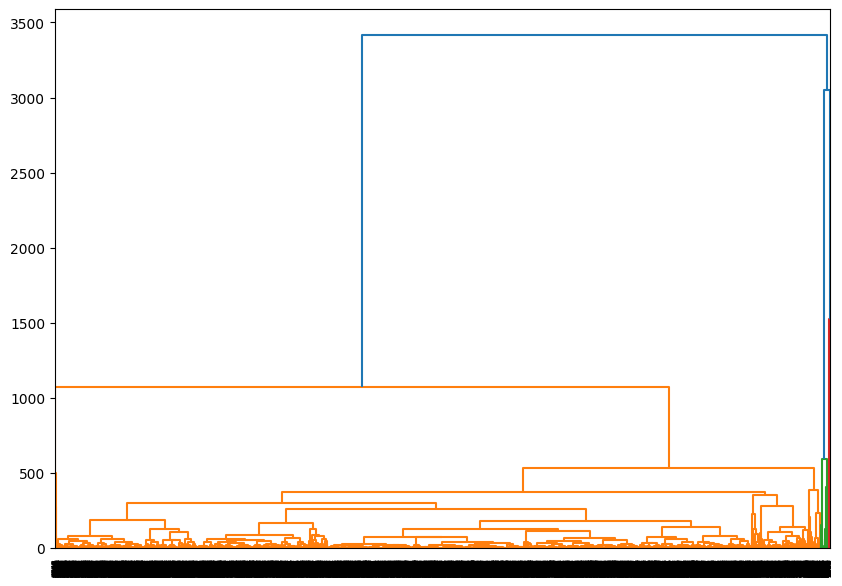

In [101]:
hierarchy= linkage(x_scaled, method='ward')
plt.figure(figsize=(10,7))
dendrogram(hierarchy)

In [102]:
agglo= AgglomerativeClustering(n_clusters=3)
y_labels= agglo.fit_predict(x_scaled)

In [103]:
print(silhouette_score(x_scaled,y_labels))

0.9499545469846338


In [104]:
df_cluster['cluster']= y_labels
df_cluster.groupby('cluster').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,0.876585,0.054545,365.994000,244.400000,125.994000,93.114338,0.140909,0.034848,0.124242,0.016667,0.200000,1.600000,6500.000000,12023.529722,422.123966,0.100000,11.800000
1,1582.150111,0.886655,1012.094929,598.696541,413.699476,989.632036,0.490391,0.204414,0.363387,0.136549,3.284294,14.802034,4507.223518,1743.802113,850.862403,0.155395,11.517288
2,0.177292,0.046362,208.559684,27.664000,180.895684,23.024881,0.504928,0.028989,0.474886,0.010543,0.105263,6.810526,3183.157895,198.643472,312.343947,0.000000,11.505263


In [121]:
dbsan= DBSCAN(eps=1.5, min_samples=20)
y_labels= dbsan.fit_predict(x_scaled)

In [122]:
print(silhouette_score(x_scaled, y_labels))

-0.20243338964465765
